In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [34]:
with open("20241113_managementInsights1_personalization_context.json", "r") as fp:
    personalization_context1 = json.load(fp)
    
with open("20241113_managementInsights2_personalization_context.json", "r") as fp:
    personalization_context2 = json.load(fp)
    
with open("20241113_managementInsights3_personalization_context.json", "r") as fp:
    personalization_context3 = json.load(fp)
    
with open("20241111_managementInsights4_personalization_context.json", "r") as fp:
    personalization_context4 = json.load(fp)
    
with open("rashomon_study_data_00c6ea43-ec5c-4b09-9cb9-b1feb8e481db.json", "r") as fp:
    dashboard_data = json.load(fp)

In [3]:
# personalization context 1: treatment group only, 
# discarded because of changed reward calibration
print(f"""managementInsights1 
total participants: {len(personalization_context1)}
treatment: {len([user_id for user_id, context in personalization_context1.items() if context["group"] == "Treatment"])}
control: {len([user_id for user_id, context in personalization_context1.items() if context["group"] == "Control"])}
""")

# personalization context 2: control group only, 
# included because reward calibration has no effect on treatment group
print(f"""managementInsights2 
total participants: {len(personalization_context2)}
treatment: {len([user_id for user_id, context in personalization_context2.items() if context["group"] == "Treatment"])}
control: {len([user_id for user_id, context in personalization_context2.items() if context["group"] == "Control"])}
""")

# personalization context 3: treatment group only, 
# included (updated reward calibration)
print(f"""managementInsights3
total participants: {len(personalization_context3)}
treatment: {len([user_id for user_id, context in personalization_context3.items() if context["group"] == "Treatment"])}
control: {len([user_id for user_id, context in personalization_context3.items() if context["group"] == "Control"])}
""")

# personalization context 4: treatment group only, 
# included (updated reward calibration)
print(f"""managementInsights4
total participants: {len(personalization_context4)}
treatment: {len([user_id for user_id, context in personalization_context4.items() if context["group"] == "Treatment"])}
control: {len([user_id for user_id, context in personalization_context4.items() if context["group"] == "Control"])}
""")

managementInsights1 
total participants: 31
treatment: 31
control: 0

managementInsights2 
total participants: 30
treatment: 0
control: 30

managementInsights3
total participants: 19
treatment: 19
control: 0

managementInsights4
total participants: 70
treatment: 41
control: 29



In [4]:
def is_treatment_participant(analytics_event: dict) -> bool:
    return analytics_event["group"] == "Treatment"

def is_control_participant(analytics_event: dict) -> bool:
    return analytics_event["group"] == "Control"

treatment_personalization_context = {
    **{key: val for key, val in personalization_context3.items() if is_treatment_participant(val)},
    **{key: val for key, val in personalization_context4.items() if is_treatment_participant(val)},
}

control_personalization_context = {
    **{key: val for key, val in personalization_context2.items() if is_control_participant(val)},
    **{key: val for key, val in personalization_context3.items() if is_treatment_participant(val)},
    **{key: val for key, val in personalization_context4.items() if is_treatment_participant(val)},
}

print(f"""DATA INCLUDED IN ANALYSIS
total participants: {len(treatment_personalization_context) + len(control_personalization_context)}
treatment group: {len(treatment_personalization_context)}
control group: {len(control_personalization_context)}
""")

DATA INCLUDED IN ANALYSIS
total participants: 150
treatment group: 60
control group: 90



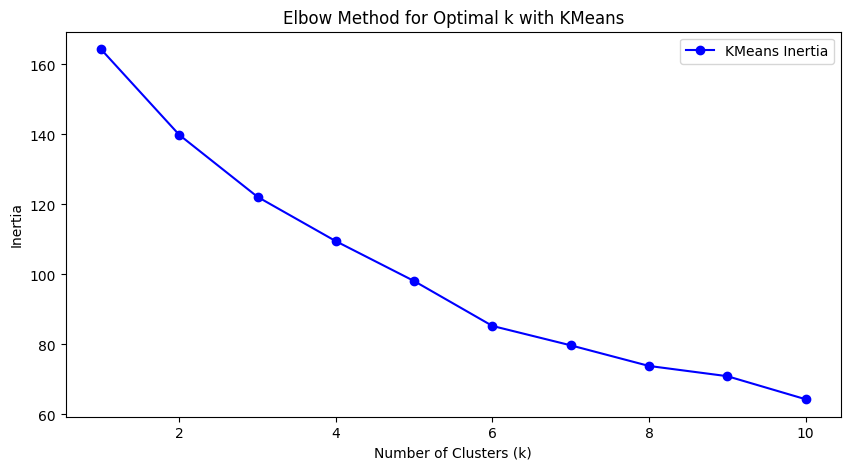

Agglomerative Clustering Cluster Sizes:

Number of Clusters: 2
Cluster 0: 43 points
Cluster 1: 17 points

Number of Clusters: 3
Cluster 0: 26 points
Cluster 1: 17 points
Cluster 2: 17 points

Number of Clusters: 4
Cluster 0: 17 points
Cluster 1: 13 points
Cluster 2: 17 points
Cluster 3: 13 points

Number of Clusters: 5
Cluster 0: 17 points
Cluster 1: 13 points
Cluster 2: 9 points
Cluster 3: 13 points
Cluster 4: 8 points

Number of Clusters: 6
Cluster 0: 13 points
Cluster 1: 13 points
Cluster 2: 9 points
Cluster 3: 8 points
Cluster 4: 8 points
Cluster 5: 9 points

Number of Clusters: 7
Cluster 0: 13 points
Cluster 1: 8 points
Cluster 2: 9 points
Cluster 3: 8 points
Cluster 4: 8 points
Cluster 5: 9 points
Cluster 6: 5 points

Number of Clusters: 8
Cluster 0: 8 points
Cluster 1: 8 points
Cluster 2: 9 points
Cluster 3: 8 points
Cluster 4: 8 points
Cluster 5: 9 points
Cluster 6: 5 points
Cluster 7: 5 points

Number of Clusters: 9
Cluster 0: 8 points
Cluster 1: 8 points
Cluster 2: 9 points
C

In [20]:
treatment_encoding_evolution = np.array([
    [np.array(response["encoding"])
     for request, response in zip(personalization_context["requestStack"], personalization_context["responseStack"][1:])
    ] for _, personalization_context in treatment_personalization_context.items()])

# Assuming encoding_evolution and data are already defined
data = treatment_encoding_evolution[:, 0, :]

# Define the range of cluster sizes to test
cluster_range = range(1, 11)  # Try k from 1 to 10 clusters

# Store inertia values for the elbow plot
kmeans_inertia = []

# Loop over each cluster size for KMeans
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data)
    kmeans_inertia.append(kmeans.inertia_)

# Plot KMeans inertia values to apply the elbow method
plt.figure(figsize=(10, 5))
plt.plot(cluster_range, kmeans_inertia, marker='o', color='b', label='KMeans Inertia')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k with KMeans')
plt.legend()
plt.show()

# Print cluster sizes for Agglomerative Clustering
print("Agglomerative Clustering Cluster Sizes:")
for n_clusters in cluster_range[1:]:  # Starting from 2 since 1 cluster won't be informative
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
    labels = agg_clustering.fit_predict(data)
    
    print(f"\nNumber of Clusters: {n_clusters}")
    for k in range(n_clusters):
        print(f"Cluster {k}: {data[labels == k, :].shape[0]} points")

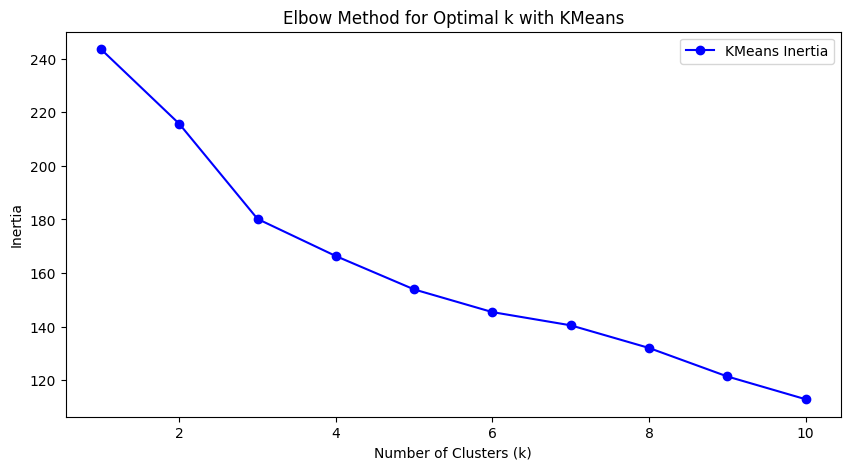

Agglomerative Clustering Cluster Sizes:

Number of Clusters: 2
Cluster 0: 60 points
Cluster 1: 30 points

Number of Clusters: 3
Cluster 0: 30 points
Cluster 1: 30 points
Cluster 2: 30 points

Number of Clusters: 4
Cluster 0: 30 points
Cluster 1: 30 points
Cluster 2: 17 points
Cluster 3: 13 points

Number of Clusters: 5
Cluster 0: 30 points
Cluster 1: 14 points
Cluster 2: 17 points
Cluster 3: 13 points
Cluster 4: 16 points

Number of Clusters: 6
Cluster 0: 20 points
Cluster 1: 14 points
Cluster 2: 17 points
Cluster 3: 13 points
Cluster 4: 16 points
Cluster 5: 10 points

Number of Clusters: 7
Cluster 0: 14 points
Cluster 1: 13 points
Cluster 2: 17 points
Cluster 3: 9 points
Cluster 4: 16 points
Cluster 5: 10 points
Cluster 6: 11 points

Number of Clusters: 8
Cluster 0: 17 points
Cluster 1: 13 points
Cluster 2: 10 points
Cluster 3: 9 points
Cluster 4: 16 points
Cluster 5: 7 points
Cluster 6: 11 points
Cluster 7: 7 points

Number of Clusters: 9
Cluster 0: 13 points
Cluster 1: 16 points
Clu

In [22]:
control_encoding_evolution = np.array([
    [np.array(response["encoding"])
     for request, response in zip(personalization_context["requestStack"], personalization_context["responseStack"][1:])
    ] for _, personalization_context in control_personalization_context.items()])

# Assuming encoding_evolution and data are already defined
data = control_encoding_evolution[:, 0, :]

# Define the range of cluster sizes to test
cluster_range = range(1, 11)  # Try k from 1 to 10 clusters

# Store inertia values for the elbow plot
kmeans_inertia = []

# Loop over each cluster size for KMeans
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data)
    kmeans_inertia.append(kmeans.inertia_)

# Plot KMeans inertia values to apply the elbow method
plt.figure(figsize=(10, 5))
plt.plot(cluster_range, kmeans_inertia, marker='o', color='b', label='KMeans Inertia')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k with KMeans')
plt.legend()
plt.show()

# Print cluster sizes for Agglomerative Clustering
print("Agglomerative Clustering Cluster Sizes:")
for n_clusters in cluster_range[1:]:  # Starting from 2 since 1 cluster won't be informative
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
    labels = agg_clustering.fit_predict(data)
    
    print(f"\nNumber of Clusters: {n_clusters}")
    for k in range(n_clusters):
        print(f"Cluster {k}: {data[labels == k, :].shape[0]} points")

<BarContainer object of 15 artists>

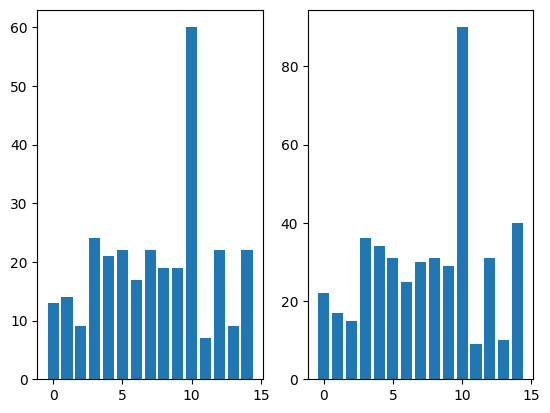

In [31]:
plt.subplot(1,2,1)
plt.bar(range(15), treatment_encoding_evolution[:,0,:].sum(axis=0))

plt.subplot(1,2,2)
plt.bar(range(15), control_encoding_evolution[:,0,:].sum(axis=0))

In [40]:
encoding_universe = np.array([json.loads(e) for e in dashboard_data["configurationData"]])

<BarContainer object of 15 artists>

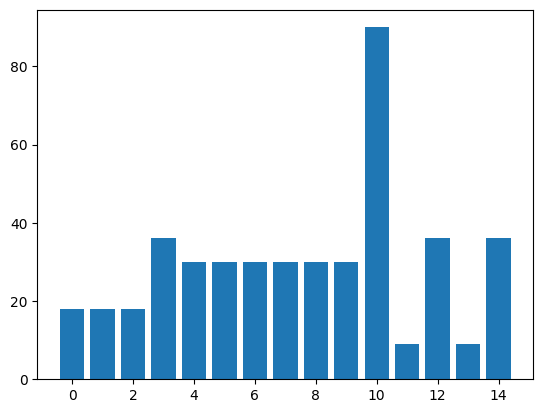

In [42]:
plt.bar(range(15), encoding_universe.sum(axis=0))

In [56]:
exclude_initial_dist = encoding_universe[:,:4].sum(axis=0) / encoding_universe.shape[0]
n_interactions_initial_dist = encoding_universe[:,4:7].sum(axis=0) / encoding_universe.shape[0]
max_bins_initial_dist = encoding_universe[:,7:10].sum(axis=0) / encoding_universe.shape[0]
monotonicity_initial_dist = encoding_universe[:,11:].sum(axis=0) / encoding_universe.shape[0]

print(exclude_initial_dist)
print(n_interactions_initial_dist)
print(max_bins_initial_dist)
print(monotonicity_initial_dist)

[0.2 0.2 0.2 0.4]
[0.33333333 0.33333333 0.33333333]
[0.33333333 0.33333333 0.33333333]
[0.1 0.4 0.1 0.4]


In [72]:
print("initial    ", exclude_initial_dist)
print("treatment  ", treatment_encoding_evolution[:,0,:].std(axis=0)[:4])
print("control    ", control_encoding_evolution[:,0,:].std(axis=0)[:4])

initial     [0.2 0.2 0.2 0.4]
treatment   [0.41197357 0.42295258 0.35707142 0.48989795]
control     [0.42975732 0.39142033 0.372678   0.48989795]


In [73]:
print("initial    ", n_interactions_initial_dist)
print("treatment  ", treatment_encoding_evolution[:,0,:].std(axis=0)[4:7])
print("control    ", control_encoding_evolution[:,0,:].std(axis=0)[4:7])

initial     [0.33333333 0.33333333 0.33333333]
treatment   [0.4769696  0.48189441 0.45061686]
control     [0.48483165 0.47518677 0.44790321]


In [74]:
print("initial    ", max_bins_initial_dist)
print("treatment  ", treatment_encoding_evolution[:,0,:].std(axis=0)[7:10])
print("control    ", control_encoding_evolution[:,0,:].std(axis=0)[7:10])

initial     [0.33333333 0.33333333 0.33333333]
treatment   [0.48189441 0.46517619 0.46517619]
control     [0.47140452 0.47518677 0.46732757]


In [75]:
print("initial    ", monotonicity_initial_dist)
print("treatment  ", treatment_encoding_evolution[:,0,:].std(axis=0)[11:])
print("control    ", control_encoding_evolution[:,0,:].std(axis=0)[11:])

initial     [0.1 0.4 0.1 0.4]
treatment   [0.32102267 0.48189441 0.35707142 0.48189441]
control     [0.3        0.47518677 0.31426968 0.49690399]


In [76]:
encoding_universe.shape

(90, 15)

In [78]:
def binary_to_decimal(binary_list):
    """
    Converts a list of binary digits (0s and 1s) to its decimal representation.

    Parameters:
    binary_list (list of int): A list of binary digits, e.g., [1, 0, 1, 1].

    Returns:
    int: The decimal representation of the binary number.
    """
    decimal = 0
    for i, bit in enumerate(reversed(binary_list)):
        decimal += bit * (2 ** i)
    return decimal




In [107]:
decimal_personalization_encodings = [binary_to_decimal(binary) for binary in treatment_encoding_evolution[:,0,:]]
encoding_frequencies = {}

for i, decimal in enumerate(decimal_personalization_encodings):
    cur = encoding_frequencies.get(decimal, 0)
    encoding_frequencies[decimal] = cur + 1
    
print(encoding_frequencies)

{5268: 1, 5265: 1, 2449: 1, 8756: 1, 3156: 1, 4660: 2, 3154: 1, 4753: 1, 16945: 2, 9361: 2, 2456: 2, 17556: 4, 16948: 2, 2392: 2, 3122: 2, 2610: 3, 2641: 1, 2354: 2, 9297: 2, 17044: 1, 9300: 1, 2616: 1, 4692: 1, 5169: 1, 3224: 1, 16980: 1, 8849: 1, 8593: 1, 2388: 1, 8529: 1, 8497: 1, 3217: 2, 4436: 2, 17489: 1, 2705: 1, 2385: 1, 8753: 1, 8596: 1, 16977: 1, 2450: 1, 8500: 1, 17492: 1, 8852: 1, 2648: 1}


In [108]:
decimal_personalization_encodings = [binary_to_decimal(binary) for binary in control_encoding_evolution[:,0,:]]
encoding_frequencies = {}
for i, decimal in enumerate(decimal_personalization_encodings):
    cur = encoding_frequencies.get(decimal, 0)
    encoding_frequencies[decimal] = cur + 1
    
print(encoding_frequencies)
    
len(encoding_frequencies)

{2356: 1, 16977: 2, 16945: 3, 4497: 1, 8529: 2, 4753: 3, 17553: 1, 2648: 2, 3121: 2, 3220: 1, 3153: 2, 3124: 1, 5204: 1, 16721: 2, 9297: 3, 17044: 2, 17492: 2, 2708: 1, 16689: 1, 17556: 5, 4689: 1, 2353: 1, 2616: 2, 5169: 2, 3154: 2, 8500: 2, 5268: 1, 5265: 1, 2449: 1, 8756: 1, 3156: 1, 4660: 2, 9361: 2, 2456: 2, 16948: 2, 2392: 2, 3122: 2, 2610: 3, 2641: 1, 2354: 2, 9300: 1, 4692: 1, 3224: 1, 16980: 1, 8849: 1, 8593: 1, 2388: 1, 8497: 1, 3217: 2, 4436: 2, 17489: 1, 2705: 1, 2385: 1, 8753: 1, 8596: 1, 2450: 1, 8852: 1}


57

In [93]:
len(decimal_personalization_encodings)

60

In [98]:
len(decimal_personalization_encodings)

60

In [99]:
len(set(decimal_personalization_encodings))

44